# Results and Conclusions - 8/13/26

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

def plot_scatter(csv_filepath, title="SPVVVECTR Observed Trials"):
    """
    Loads BO trial data from CSV and outputs 3d scatter plot.
    Fitness (displacement) is represented by both color (heat) and marker size
    """
    df = pd.read_csv(csv_filepath, nrows=50)

    # pick the displacement column once, then reuse it
    disp_col = 'Displacement_mm' if 'Displacement_mm' in df.columns else 'Displacement_mm_mean'

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        df['RPM_1'],
        df['RPM_2'],
        df['RPM_3'],
        c=df[disp_col],
        cmap='inferno',
        s=df[disp_col].clip(lower=0) * 0.8,   # clip guards against negative displacements
        alpha=0.8,
        edgecolors='w',
        linewidth=0.5
    )

    ax.set_xlabel('Strut 1 (RPM)', labelpad=10)
    ax.set_ylabel('Strut 2 (RPM)', labelpad=10)
    ax.set_zlabel('Strut 3 (RPM)', labelpad=10)
    ax.set_title(title, pad=20, fontsize=14)

    cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    label = 'Mean Displacement (mm), n=3' if disp_col.endswith('_mean') else 'Displacement (mm)'
    cbar.set_label(label, rotation=270, labelpad=20)

    plt.tight_layout()
    plt.show()

def print_top_5_gaits(csv_filepath, experiment_name="Experiment"):
    """
    Reads a Bayesian Optimization CSV, finds the top 5 highest displacements,
    and prints them as a clean, aligned text table suitable for a code block.
    """
    # 1. Load only the 50 trial rows to avoid the summary block at the bottom
    df = pd.read_csv(csv_filepath, nrows=50)
    
    # 2. Sort by displacement in descending order (highest to lowest)
    if 'Displacement_mm' in df.columns:
        top_5 = df.sort_values(by="Displacement_mm", ascending=False).head(5)
    else:
        top_5 = df.sort_values(by="Displacement_mm_mean", ascending=False).head(5)

    # 3. Print the Title
    print(f"    Top 5 Best Gaits: {experiment_name}")
    
    # 4. Print the aligned header
    header = f"{'Rank':<5} | {'Prior/Opt':<13} | {'Strut 1':<8} | {'Strut 2':<8} | {'Strut 3':<8} | {'Displacement (mm)':<17}"
    print(header)
    print("-" * len(header))
    
    # 5. Iterate through the top 5 and print aligned rows
    rank = 1
    for index, row in top_5.iterrows():
        phase = row['Phase']
        rpm1 = int(row['RPM_1'])
        rpm2 = int(row['RPM_2'])
        rpm3 = int(row['RPM_3'])
        if 'Displacement_mm' in row:
            disp = f"{row['Displacement_mm']:.2f}"
        else:
            disp = f"{row['Displacement_mm_mean']:.2f}"

        # The :< number forces the text to take up exactly that many spaces
        print(f"{rank:<5} | {phase:<13} | {rpm1:<8} | {rpm2:<8} | {rpm3:<8} | {disp:<17}")
        rank += 1

def plot_convergence():
    # file paths
    experiments = {
        "Random Priors": "../../data/bo_experiment_SPVVVECTR-1a/bo_results_random_priors/bo_results_20260728_141100.csv",
        "LHS Priors": "../../data/bo_experiment_SPVVVECTR-1a/bo_results_lhs_priors/bo_results_20260728_143448.csv",
        "Minimal Priors (~10 randoms)": "../../data/bo_experiment_SPVVVECTR-1a/bo_results_no_priors/bo_results_20260728_150129.csv"
    }

    plt.figure(figsize=(10, 6))

    for label, filepath in experiments.items():
        df = pd.read_csv(filepath, nrows=50)
        
        df['Best_So_Far'] = df['Displacement_mm'].cummax()
        plt.plot(df['Trial_Number'], df['Best_So_Far'], label=label, marker='o', markersize=4)

    # formatting
    plt.xlabel('Trial Number', fontsize=12)
    plt.ylabel('Best Displacement (mm)', fontsize=12)
    plt.title('Bayesian Optimization Convergence', fontsize=14, pad=15)

    # legend
    plt.legend(loc="upper left")
    plt.grid(True, linestyle='-', alpha=0.7)

    plt.tight_layout()
    plt.show()
        

## *Part 0*

### Background

Tensegrity structures consist of rigid struts held in place by a network of cables. While tensegrities are naturally resilient from these properties, they are also very difficult to control. With vibrationally actuated tensegrities, small changes in motor frequency can result in big differences in movement, much of it being non-linear and unpredictable.

SPVVVECTR is a 3-motor tensegrity robot that locomotes through vibration. Each motor can have an RPM range between -1000 and 1000, so testing which inputs have effective locomotive capability is not possible with hand-trials. Also, previous empirical trialing demonstrated that higher RPMs (such as max values) usually led to higher displacements. However, it is my goal to determine the efficacy of a machine learning algorithm such as Bayesian Optimization in generating optimal inputs that empirical testing could not find. 

Every input is a 20-second trial throughout our experiments and we decided to make our fitness function the linear displacement over the course of a 20-second trial.

### Robots Tested

1. **SPVVVECTR-1a**:
    First robot, lighter springs and overall lighter weight. Therefore easier to move with lesser RPMs.

2. **SPVVVECTR-1b**:
    Second robot, heavier springs and overall heavier body. Therefore displacements across the board were less. 



### Qualisys Motion Capture

All displacement tracking was done utilizing NSF-funded Qualisys motion capture system that recorded infrared signals from markers placed on SPVVVECTR to stream live 6-DOF Pose data. 

Then, I programmed Python scripts leveraging the QTM API that makes possible closed-loop optimization trials with SPVVVECTR. Below is a brief description of this loop:

1. The optimizer proposes an RPM-input.
2. The input is sent to SPVVVECTR's controller over BLE.
3. QTM streams live positional data for the duration of the 20-second trial.
4. Net linear displacement from initial position to final position is automatically computed and brought to the attention to the user.
5. The user manually presses `s` to return displacement to optimizer, or `r` to discard and retry trial
6. If (5) is `s`, The optimizer updates its surrogate model and proposes next input. 



### Bayesian Optimization

The optimizer was programmed with `scikit-optimize` using the ask-tell `Optimizer` methods. This way, each proposed input could be physically run before the next one was requested. 

The surrogate model was a `GaussianProcessRegressor` with a Matérn kernel ($\nu = 2.5$), `normalize_y=True`, and Gaussian noise estimation. Then, the acquisition function was Expected Improvement (EI). The search space was 3 dimensional on the set of Integers between $[-1000, 1000]$ RPM per strut. Since `skopt` minimizes by default, we had to negate our displacement when inputting through `opt.tell()`. LHS Priors were generated with `Lhs(lhs_type="classic")` over the search space. Random priors were uniformly random. 


### Different Trial Protocols

Conducted over 300 trials, all 20-seconds each. Throughout experimentation, we identified two separate protocol methods to run these 20-second optimization trials. Detailed below are these protocols: 

1. **constant-pose**: Here we give SPVVVECTR a constant starting point and orientation that we manually reset following every trial. This protocol became later preferred because variability in displacements was far less of an issue here.

2. **variable-pose**: This was our first protocol that was used for the majority of experiments. Here, we did not interfere as much with resetting the robots position/orientation between trials, unless SPVVVECTR was almost outside camera bounds or too close to an obstacle. Variability in displacement was much more of an issue here because our experiment arena had a slight incline. Therefore two equal RPM-inputs could have vastly different outcomes from marginal differences in starting position and orientation. Despite this, our optimizer delivered optimistic results under these conditions that we'll go over later.  

## *Part 1*
### Comprehensive Prior Experiment w/ SPVVVECTR-1a

SPVVVECTR-1a was utilized to test the efficacy of different prior-acquisition strategies. My hypothesis was that a more comprehensive prior-batch across the parameter-space meant more context for the optimization steps to therefore find fit inputs more effectively.

Our parameter space can be denoted as follows:

$P = \{ (x, y, z) \in \mathbb{Z}^3 \mid -1000 \leq x, y, z \leq 1000 \}$

My first 3 experiments tested this hypothesis with 3 respective prior-acquisition strategies. Note that these 3 experiments were ran with **variable-pose** protocol:

1. Random Priors
2. Latin Hypercube Sampling
3. Minimal Random Priors (~10 randoms)

For (1) and (2), I ran 15 priors and then ran 35 optimization steps.

For (3), the purpose was to avoid priors, and simply run 50 optimization steps. However, because of a few technical issues, the program automatically took 10 random priors to get a baseline. However, this still led to a distinct outcome from the 15 random priors.

The scatter plots below showcase the different distributions in where the optimizer chose to focus its search. Each axis represents a motor, and the heat (color) represents our fitness, the linear displacement. Below each scatter are the top 5 displacing inputs the optimizer produced. 

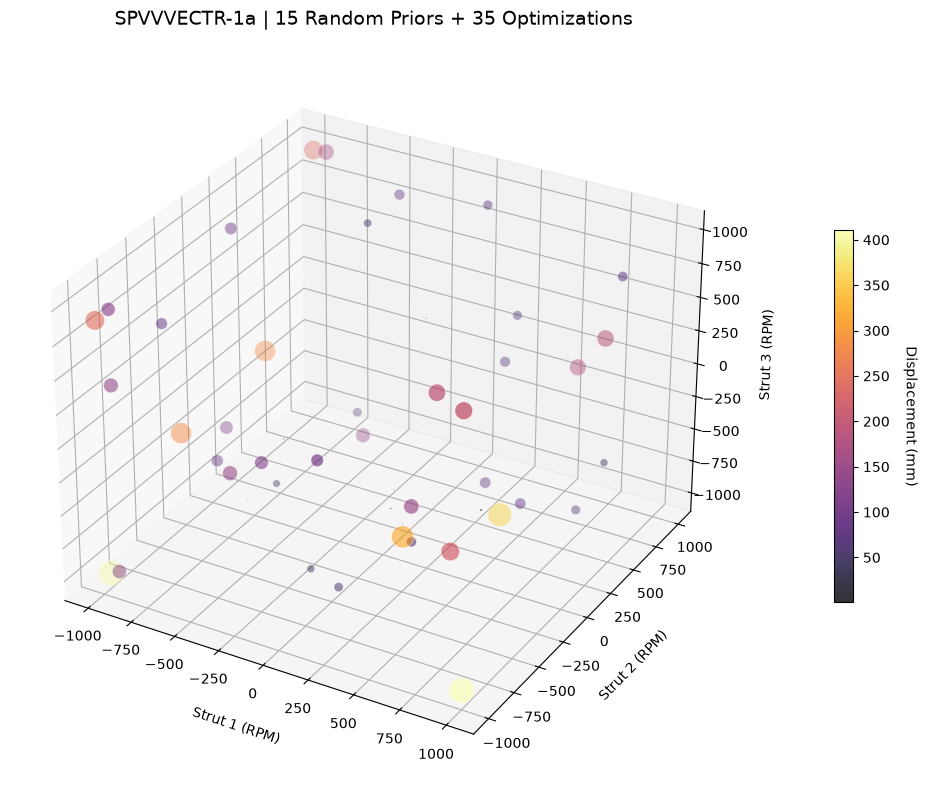

    Top 5 Best Gaits: SPVVVECTR-1a | 15 Random Priors + 35 Optimizations
Rank  | Prior/Opt     | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 1000     | -1000    | -1000    | 410.76           
2     | Optimization  | -974     | -970     | -991     | 404.64           
3     | Optimization  | 789      | -252     | -331     | 364.35           
4     | Prior         | 592      | -844     | -154     | 318.03           
5     | Optimization  | -847     | -508     | -196     | 282.12           


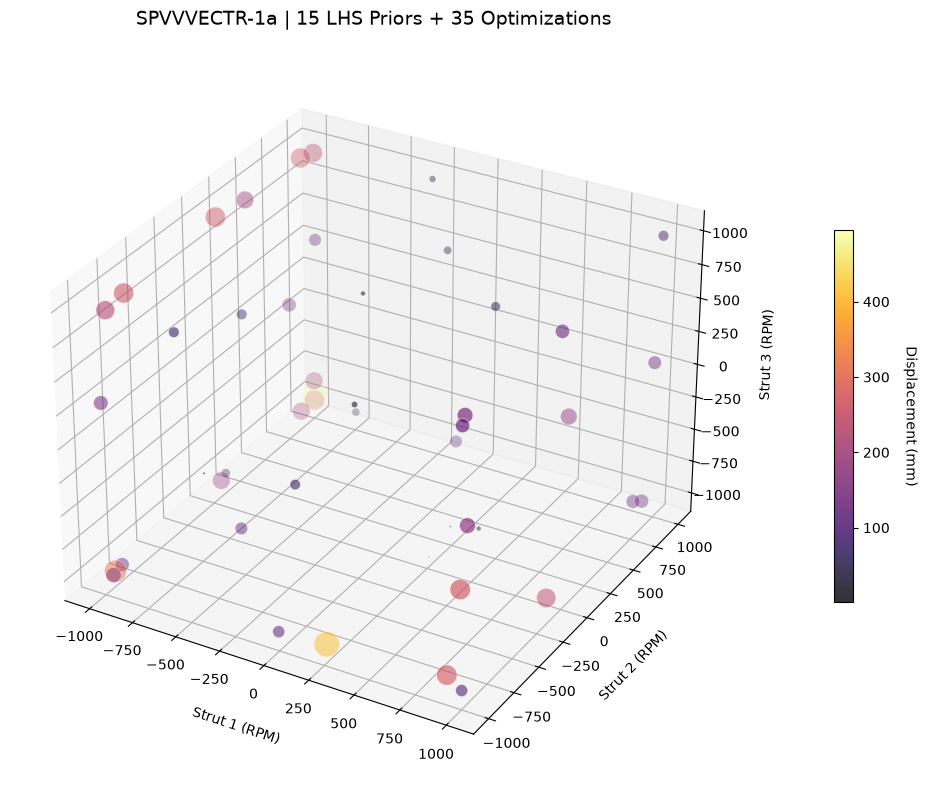

    Top 5 Best Gaits: SPVVVECTR-1a | 15 LHS Priors + 35 Optimizations
Rank  | Prior/Opt     | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | -1000    | 1000     | -963     | 495.06           
2     | Optimization  | 258      | -989     | -989     | 419.55           
3     | Optimization  | -964     | -963     | -974     | 310.05           
4     | Optimization  | 979      | -987     | -269     | 268.92           
5     | Optimization  | 911      | -984     | -936     | 268.06           


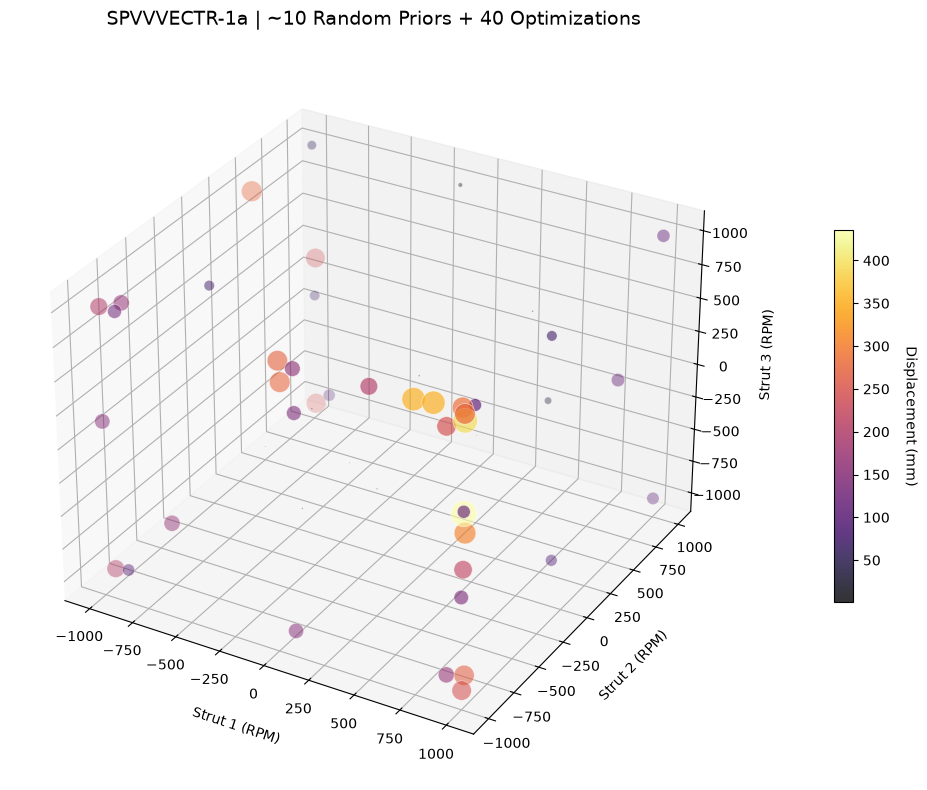

    Top 5 Best Gaits: SPVVVECTR-1a | ~10 Random Priors + 40 Optimizations
Rank  | Prior/Opt     | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 1000     | -1000    | 297      | 435.57           
2     | Optimization  | 993      | -984     | 939      | 395.49           
3     | Optimization  | 734      | -1000    | 1000     | 352.87           
4     | Optimization  | 828      | -983     | 1000     | 351.37           
5     | Optimization  | 997      | -980     | 143      | 305.52           


In [67]:
path_1 = './../../data/bo_experiment_SPVVVECTR-1a/bo_results_random_priors/bo_results_20260728_141100.csv'
path_2 = '../../data/bo_experiment_SPVVVECTR-1a/bo_results_lhs_priors/bo_results_20260728_143448.csv'
path_3 = '../../data/bo_experiment_SPVVVECTR-1a/bo_results_no_priors/bo_results_20260728_150129.csv'

plot_scatter(path_1, 'SPVVVECTR-1a | 15 Random Priors + 35 Optimizations')
print_top_5_gaits(path_1, 'SPVVVECTR-1a | 15 Random Priors + 35 Optimizations')
plot_scatter(path_2, 'SPVVVECTR-1a | 15 LHS Priors + 35 Optimizations')
print_top_5_gaits(path_2, 'SPVVVECTR-1a | 15 LHS Priors + 35 Optimizations')
plot_scatter(path_3, 'SPVVVECTR-1a | ~10 Random Priors + 40 Optimizations')
print_top_5_gaits(path_3, 'SPVVVECTR-1a | ~10 Random Priors + 40 Optimizations')

**Takeaway** 

What to takeaway from these experiments are the distribution of inputs our optimizers chose to focus on. Because of further spread in our random and LHS priors, our optimizer searched far more of our parameter-space, $P$. Although many of these random and LHS priors showcased very weak displacements, our optimizer was able to leverage that information in deciding future observations. 

In contrast, our minimal prior experiment showcases a far more pigeon-holed distribution of points because it seems that our optimizer plateaued at a local maximum. Then, most of the search space remains far emptier than the other two strategies. 

Below is a convergence plot that demonstrates this plateau effect for all 3 strategies. This plot illustrates the much quicker ability for the minimal prior strategy to find more optimal displacements in the beginning. However, since the search-space is far less contextualized in this strategy, we run into a concentration of observations in a specific area of the parameter space. Other strategies therefore caught up and generated more optimal displacements a few trials after. 

Note that because of the variability of the same input, especially under **variable-pose** protocol, we would have to replicate this experiment with greater sample sizes and **constant-pose** to truly demonstrate the efficacy of LHS priors. However, these experiments led me to primarily utilize LHS priors for future experiments in determining optimal gaits.

Also a side note is how many of the top gaits in each trial hold max RPMs (i.e. 1000, -1000). This follows empirical understanding that higher RPM frequencies cause higher displacements. However, these higher displacements also demonstrate the most variability and unpredictability compared to reduced frequencies. As mentioned in the background, we will get into in part 3 how machine learning may be able to find a 'sweet-spot' input that is more predictable than max frequencies, yet also higher displacing than slow frequencies. 

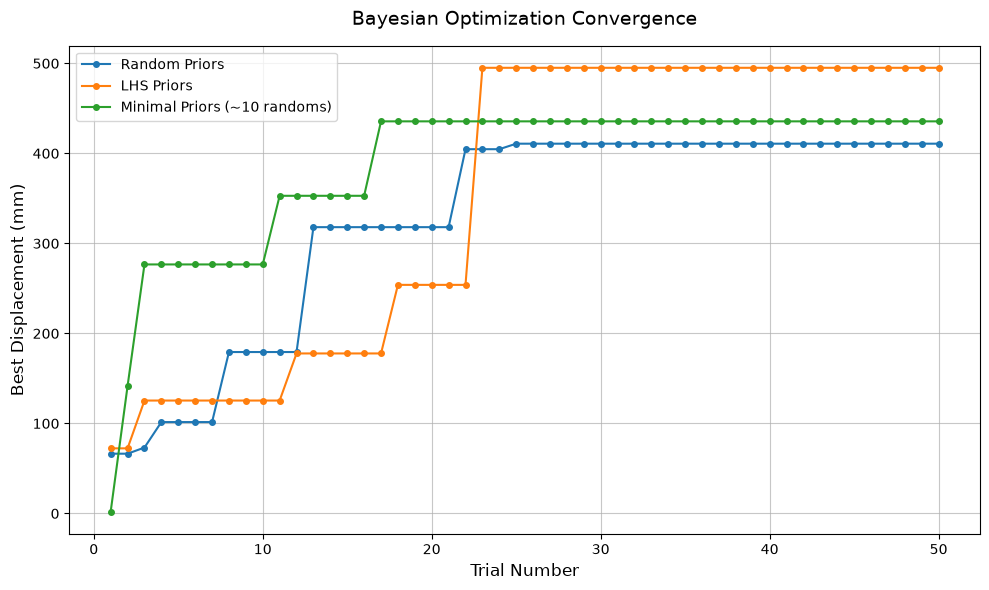

In [68]:
plot_convergence()

## *Part 2*
### Protocol Testing w/ SPVVVECTR-1b 

In [69]:
def plot_protocol_variance(protocols, title="Displacement Variability by Protocol"):
    """
    Compares displacement distributions across trial protocols with a box plot.
    protocols: dict of {label: csv_filepath}, each CSV having a 'Displacement_mm' column.
    Prints mean, std, and coefficient of variation for each, plus the percent
    difference between the highest and lowest mean.
    """
    # load each protocol's displacements
    data, labels = [], []
    for label, filepath in protocols.items():
        df = pd.read_csv(filepath)
        data.append(df['Displacement_mm'])
        labels.append(label)

    # box plot
    plt.figure(figsize=(8, 6))
    bp = plt.boxplot(data, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=1.5))
    plt.xticks(range(1, len(labels) + 1), labels)

    # color each box
    for patch, color in zip(bp['boxes'], ['#f1a340', '#998ec3']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # overlay raw trials so sample size is visible
    for i, series in enumerate(data, start=1):
        plt.scatter([i] * len(series), series, color='black', alpha=0.6, s=25, zorder=3)

    plt.ylabel('Displacement (mm)', fontsize=12)
    plt.title(title, fontsize=14, pad=15)
    plt.grid(True, axis='y', linestyle='-', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # summary statistics
    print(f"{'Protocol':<20} | {'n':<4} | {'Mean (mm)':<10} | {'Std (mm)':<10} | {'CV':<6}")
    print("-" * 66)
    means = {}
    for label, series in zip(labels, data):
        mean, std = series.mean(), series.std()
        means[label] = mean
        print(f"{label:<20} | {len(series):<4} | {mean:<10.2f} | {std:<10.2f} | {std/mean:<6.3f}")


Following SPVVVECTR-1a's experiments, I became more interested in utilizing **constant-pose** for future experiments. I was curious of the variability that the same input caused if it was given the same starting point and orientation for every trial. 

For this experiment, we took a baseline vertex input, $[1000, 1000, 1000]$, and ran 2 tests to compare variability between **constant-pose** and **variable-pose** trials. Each had a sample size of 10, and we ran both protocols back-to-back. 

Below is a box plot that illustrates the different outcomes that the same input can lead to depending on the testing protocol. I found that under **constant-pose**, the standard deviation of displacements was cut by more than half than in the **variable-pose** protocol. 

However, testing with only one constant starting-point misses the goal of a vibrationally-actuated tensegrity like SPVVVECTR, which is to locomote on multiple surfaces and orientations. So while **constant-pose** proved more effective for variance testing specific RPM-inputs, I was going to utilize both protocols for my next step in finding optimal gaits for SPVVVECTR-1b.


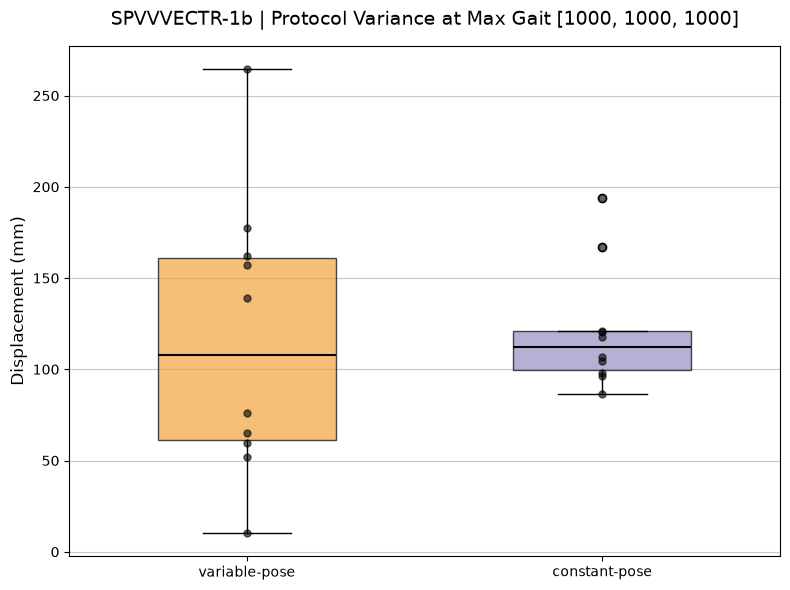

Protocol             | n    | Mean (mm)  | Std (mm)   | CV    
------------------------------------------------------------------
variable-pose        | 10   | 116.42     | 76.62      | 0.658 
constant-pose        | 10   | 121.29     | 33.79      | 0.279 


In [70]:
protocols = {
    "variable-pose": '../../data/bo_experiment_SPVVVECTR-1b/benchmark_testing/benchmark_repositioning_difference/no_repositioning_variance_results_[1000, 1000, 1000].csv',
    "constant-pose": '../../data/bo_experiment_SPVVVECTR-1b/benchmark_testing/benchmark_repositioning_difference/repositioning_variance_results_[1000, 1000, 1000].csv'
}
plot_protocol_variance(protocols, "SPVVVECTR-1b | Protocol Variance at Max Gait [1000, 1000, 1000]")

## *Part 3*
### Generating Inputs & Unexpected Morphologies (SPVVVECTR-1b)

In [71]:
def _disp(df):
    """Returns the displacement column, whichever naming the CSV uses."""
    for col in ('Displacement_mm', 'Linear_Displacement_mm', 'Displacement_mm_mean'):
        if col in df.columns:
            return df[col]
    raise KeyError("No displacement column found.")


def plot_trial_series(datasets, title="Displacement Across Trials", events=None):
    """
    Plots displacement in run order (trial number on x-axis) for one or more tests.
    Reveals drift, plateaus, and intermittent failures that distribution plots hide.

    datasets: dict of {label: csv_filepath}
    events:   optional dict of {trial_number: 'annotation text'} drawn as vertical lines
    """
    plt.figure(figsize=(11, 6))
    colors = ['#d95f02', '#7570b3', '#1b9e77', '#e7298a']

    stats = {}
    for (label, filepath), color in zip(datasets.items(), colors):
        df = pd.read_csv(filepath)
        disp = _disp(df)
        trials = df['Trial_Number']
        plt.plot(trials, disp, marker='o', markersize=5, linewidth=1.4,
                 color=color, label=label, alpha=0.85)
        plt.axhline(disp.mean(), color=color, linestyle='--', linewidth=1, alpha=0.4)
        stats[label] = (len(disp), disp.mean(), disp.std(), disp.std() / disp.mean())

    if events:
        for trial, text in events.items():
            plt.axvline(trial, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
            plt.text(trial, plt.ylim()[1] * 0.97, f' {text}', rotation=90,
                     va='top', ha='left', fontsize=9, alpha=0.8)

    plt.xlabel('Trial Number', fontsize=12)
    plt.ylabel('Displacement (mm)', fontsize=12)
    plt.title(title, fontsize=14, pad=15)
    plt.grid(True, linestyle='-', alpha=0.5)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"{'Test':<34} | {'n':<4} | {'Mean (mm)':<10} | {'Std (mm)':<9} | {'CV':<6}")
    print("-" * 78)
    for label, (n, mean, std, cv) in stats.items():
        print(f"{label:<34} | {n:<4} | {mean:<10.2f} | {std:<9.2f} | {cv:<6.3f}")

def plot_displacement_vectors(csv_filepath, title="Per-Trial Displacement Vectors"):
    """
    Plots each trial's net displacement as a vector from the origin in the
    ground plane, colored by trial order. Shows directional consistency --
    i.e. whether a gait travels a repeatable heading or scatters.
    Requires 'x_change_mm' and 'y_change_mm' columns.
    """
    df = pd.read_csv(csv_filepath)

    fig, ax = plt.subplots(figsize=(8, 8))
    colors = plt.cm.viridis(df['Trial_Number'] / df['Trial_Number'].max())

    for (_, row), color in zip(df.iterrows(), colors):
        ax.annotate("", xy=(row['x_change_mm'], row['y_change_mm']), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8, alpha=0.85))

    lim = max(abs(df['x_change_mm']).max(), abs(df['y_change_mm']).max()) * 1.15
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='grey', lw=0.8); ax.axvline(0, color='grey', lw=0.8)
    ax.set_aspect('equal')
    ax.set_xlabel('X Displacement (mm)', fontsize=12)
    ax.set_ylabel('Y Displacement (mm)', fontsize=12)
    ax.set_title(title, fontsize=14, pad=15)
    ax.grid(True, linestyle='-', alpha=0.4)

    sm = plt.cm.ScalarMappable(cmap='viridis',
        norm=plt.Normalize(vmin=df['Trial_Number'].min(), vmax=df['Trial_Number'].max()))
    fig.colorbar(sm, ax=ax, shrink=0.7, label='Trial Number')
    plt.tight_layout(); plt.show()

    headings = np.degrees(np.arctan2(df['y_change_mm'], df['x_change_mm']))
    print(f"Mean heading: {headings.mean():.2f} deg  (std {headings.std():.2f} deg)")
    print(f"Mean yaw change: {df['yaw_change_deg'].mean():.2f} deg  (std {df['yaw_change_deg'].std():.2f} deg)")

Following our protocol testing, I began running optimizations with LHS priors on our rebuilt robot. I conducted 2 experiments: 

1. 15 LHS Priors + 35 Optimization Trials; Sample size of n=3 per trial; **variable-pose**
2. 15 LHS Priors + 35 Optimization Trials; Sample size of n=1 per trial; **constant-pose**


With n=3 for the **variable-pose** experiment, I could account for some of the per-trial outliers that were more likely from varying start positions. In total, 200 20-second trials were conducted for these 2 experiments. 

**Best Inputs Found**
* *constant-pose*) This experiment generated a fittest non-vertex RPM-input at $[886, -24, 479]$ with a respective displacement of 254.78mm. 
* *variable-pose*) This experiment's fittest RPM-input was at $[982, 414, -301]$ with a respective displacement of 253.66mm. 

**A Closer Look**

While at first glance it seemed that both fittest inputs were on-par with one another, increased sample sizes for both inputs changed that assumption.

The variance experiments are as follows:
1. [982, 414, -301]; n=10; **constant-pose**
2. [886, -24, 479]; n=20; **constant-pose**

Plots below illustrate results:

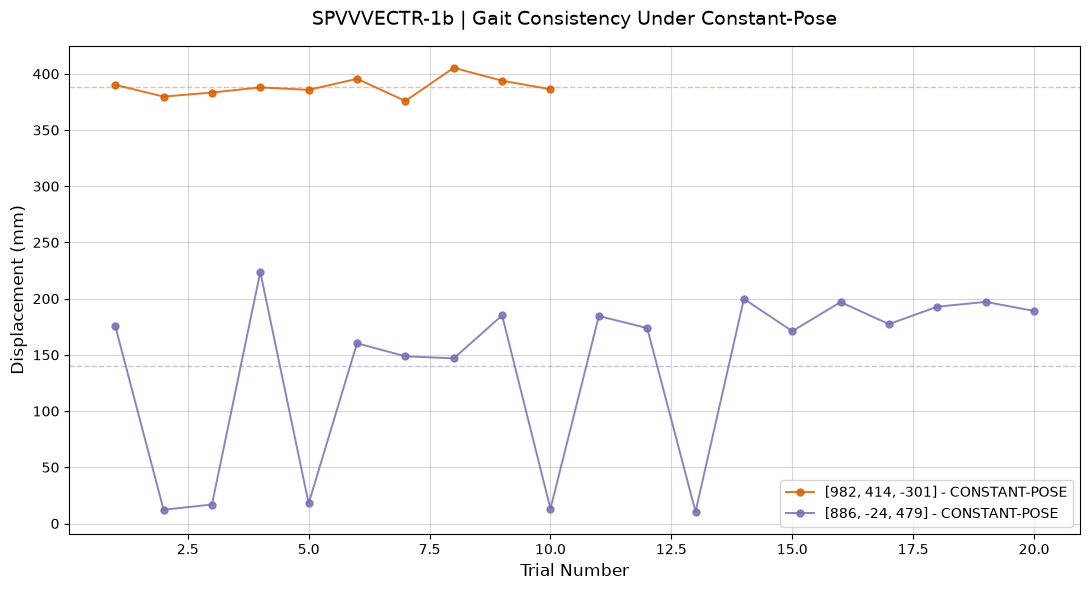

Test                               | n    | Mean (mm)  | Std (mm)  | CV    
------------------------------------------------------------------------------
[982, 414, -301] - CONSTANT-POSE   | 10   | 388.38     | 8.45      | 0.022 
[886, -24, 479] - CONSTANT-POSE    | 20   | 139.69     | 76.39     | 0.547 


In [72]:
# plot_trial_series(
#     {"[982, 414, -301] - VARIABLE-POSE": '../../data/bo_experiment_SPVVVECTR-1b/lhs/experiment1_8-3-26/fittest_gait_variance_testing/variance_results_[982, 414, -301]_1.csv'},
#     "SPVVVECTR-1b | Drift Under Variable Starting Position",
#     events={29: 'batteries replaced'}
# )

plot_trial_series({
    "[982, 414, -301] - CONSTANT-POSE": '../../data/bo_experiment_SPVVVECTR-1b/lhs/experiment1_8-3-26/fittest_gait_variance_testing/variance_results_[982_414_-301]_2.csv',
    "[886, -24, 479] - CONSTANT-POSE":'../../data/bo_experiment_SPVVVECTR-1b/lhs/experiment2_8-4-26/lhs_bo_testing/variance_results_[886, -24, 479]1.csv',
    #"[1000, 1000, 1000] - CONSTANT-POSE":  '../../data/bo_experiment_SPVVVECTR-1b/benchmark_testing/benchmark_repositioning_difference/repositioning_variance_results_[1000, 1000, 1000].csv',
}, "SPVVVECTR-1b | Gait Consistency Under Constant-Pose")

**Takeaway and Further Questions**

Let us denote input [982, 414, -301] as $g_a$ and [886, -24, 479] as $g_b$

This data showcased the sheer differences that simply was not present during the Bayesian Optimization trials. I believe part of this is attributed to luck in our choice of orientation of the robot, since that orientation likely helped $g_a$ leverage its parameters to its fullest potential. It is also important to note that since we used n=1 sample size for the **constant-pose** experiment, that it may have just been an outlier. Overall, we also took away from this experiment that n=1 sampling is not as effective for optimization algorithms.

However, this also raises new questions for how effective $g_b$ could have been if we experimented with multiple orientations, or, if we had built a robot with more motors so that orientation does not matter. 

**More Importantly**

$g_a$ proved to be a successful non-vertex input when measuring merely linear displacement, however there was another revolution this input led to.

After a few empirical trials, we found that the behavior of this input was oddly consistent in resembling a linear straight-line motion, despite the fitness function only being linear displacement. 

This idea was investigated when incorporating single-axis displacements and yaw-metrics in the tracking scripts. Below is a concrete visualization of the consistency this input gave: 


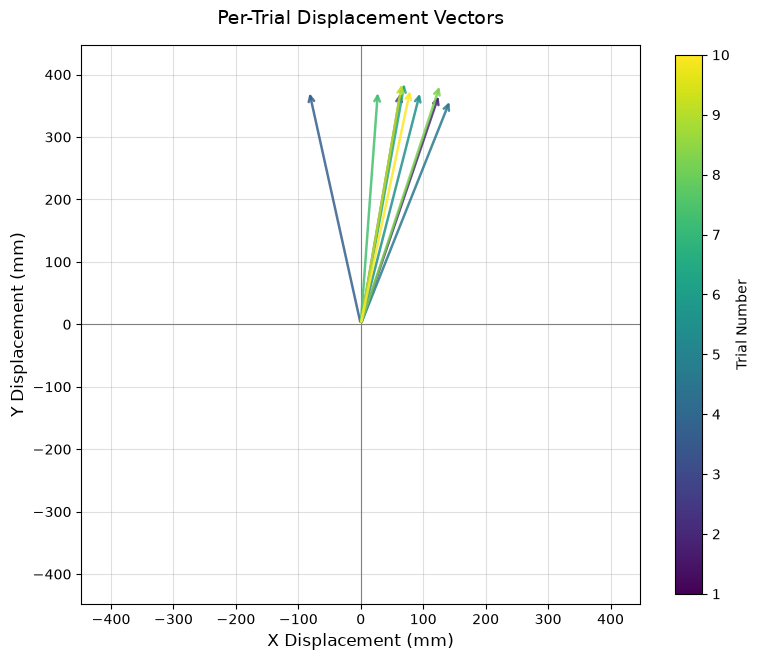

Mean heading: 79.34 deg  (std 9.68 deg)
Mean yaw change: -45.10 deg  (std 5.59 deg)


In [73]:
plot_displacement_vectors('../../data/bo_experiment_SPVVVECTR-1b/lhs/experiment1_8-3-26/fittest_gait_variance_testing/variance_results_[982_414_-301]_2.csv')

This illustrates the efficacy of Bayesian Optimization -- that how, in attempting to maximize linear displacement, the algorithm inadvertently decided that the best way to do so is an input that kept almost a constant 45 degree rotation. On the other hand, inputs empirically found typically fall within 2 categories:

1. Slow RPM; predictable; low displacement.

2. High RPM; unpredictable, constantly changing rotation; usually high displacement.

However with a machine learned RPM-input, we achieved predictability and high displacements. 

$g_a$ was a very optimistic finding, and could not have been predicted empirically. Baseline empirical assumptions of optimal inputs usually featured vertex inputs. This also sheds light on eventually achieving single-axis movement-input, and a controlled rotation-input such that we can achieve a controller abstracting away RPM-inputs.

A final experiment afterwards was directly comparing $g_a$ against [1000, 1000, 1000], denoted as $g_v$. 

## *Part 4*
### $g_a$ VS $g_v$

Testing $g_a$ against $g_v$ directly in the same testing session was essential rather than relying on the previous data-set because we find that results can vary depending on the state of battery, and other external variables. To minimize these variables, back-to-back testing was important.

Below are the results of this comparison, with a sample size n=20 for each.

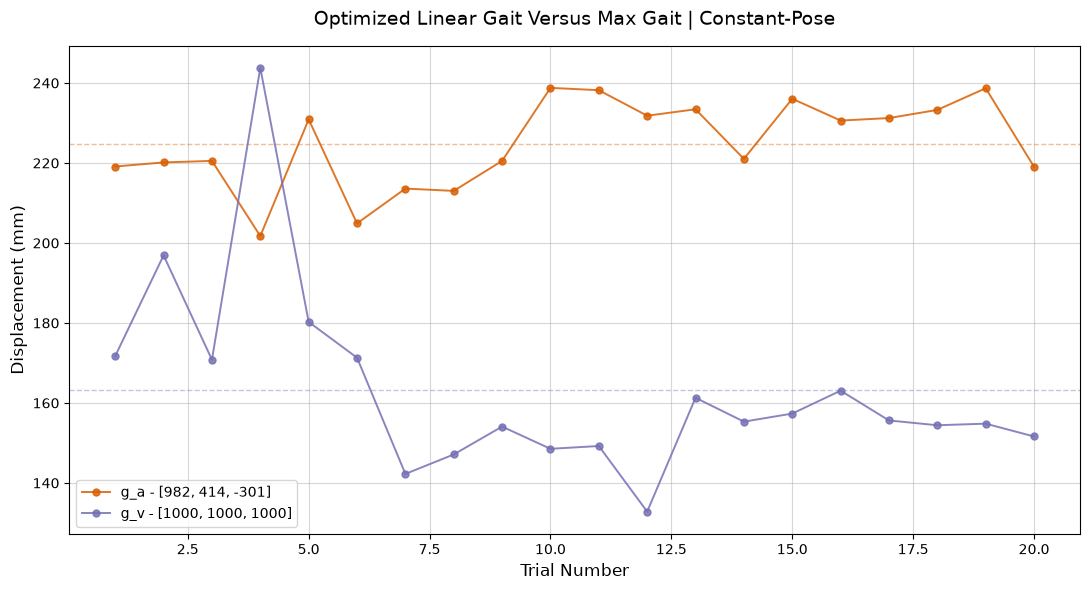

Test                               | n    | Mean (mm)  | Std (mm)  | CV    
------------------------------------------------------------------------------
g_a - [982, 414, -301]             | 20   | 224.83     | 11.08     | 0.049 
g_v - [1000, 1000, 1000]           | 20   | 163.12     | 23.70     | 0.145 


In [77]:
data = {
    'g_a - [982, 414, -301]':'../../data/bo_experiment_SPVVVECTR-1b/benchmark_testing/benchmark_against_linear_gait_NO_YAW/constant_orientation_pose_variance_results_[982, 414, -301].csv',
    'g_v - [1000, 1000, 1000]':'../../data/bo_experiment_SPVVVECTR-1b/benchmark_testing/benchmark_against_linear_gait_NO_YAW/constant_orientation_pose_variance_results_[1000, 1000, 1000].csv'
}
plot_trial_series(data, 'Optimized Linear Gait Versus Max Gait | Constant-Pose')

**Takeaway**

As we see from the data, $g_a$ displaces SPVVVECTR-1b 37.8% farther than our baseline $g_v$ and was 2.95x more consistent. 

It is worth noting that the $g_v$ outlier value that outperforms every other point in both series demonstrates the unpredictability issue with high frequency RPMs we touched on earlier. Although capable, $g_v$ is far from reliable. 

$g_a$ was generated with machine learning, and its ability to beat baseline inputs showcases the efficacy of utilizing Bayesian Optimization in RPM-input prediction. 

## *Part 5*
### Conclusion & Future Work

With over 300 trials, several experiments, and 2 robots experimented with, the past 8 weeks of research have led to many optimistic results and many more questions. 

For future work, I am curious about increasing RPM capabilities to reaching to 5000 and also increasing the number of motors. At the moment, orientation matters heavily, so creating a uniform motor setup may alleviate some of the placement issues we faced. Beyond this, I believe other machine learning algorithms can be leveraged as well with SPVVVECTR. Previous research at the UnionEvoLab worked with MAP-Elites to create a map of input behaviors. However, one of the newly found goals I am to achieve is creating a controller and abstracting away from manual RPM-inputs. I believe that altering our optimizer's fitness function from linear displacement has the capability to output desired inputs that we can leverage and make a map from. Simply, all we would need is a rotation gait and single-axis gait. 

Overall, there is much potential in the field of vibrational tensegrities, and 8 weeks of research has been an invaluable experience for my discovery of new fields, my ability to problem-solve, my collaboration skills, and my personal curiosity. 

